# Homework 3 — Vector Operations on Word Embeddings

**Discipline:** Numerical Programming in Python

**Program:** M.S. in AI/ML Engineering — Neoversity

Word embeddings turn words into vectors, which makes linear algebra a tool for semantics: the dot product measures how similar two words are, and the angle between vectors is the standard way to read that similarity off. Here the 300-dimensional vectors of a word2vec subset are projected into 3D so that the cross product is defined as well, and the three operations — dot product, cross product, angle — are applied to words and interpreted.

In [1]:
# Environment setup & imports
import pathlib
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3})
RANDOM_STATE = 42

## Step 1: A DataFrame of Three-Dimensional Word Vectors

The model file `word_embeddings_subset.p` is a pickled dictionary `{word: vector}`. It has to sit next to the notebook; in Colab it is enough to upload it, which puts it into `/content`.

In [2]:
FILE_NAME = "word_embeddings_subset.p"
candidates = [pathlib.Path(FILE_NAME), pathlib.Path("/content") / FILE_NAME]
model_path = next((path for path in candidates if path.exists()), None)

if model_path is None:
    raise FileNotFoundError(f"Put {FILE_NAME} next to the notebook (in Colab: upload it to /content).")

with open(model_path, "rb") as fh:
    embeddings = pickle.load(fh)

words = list(embeddings)
original_vectors = np.vstack([embeddings[word] for word in words]).astype(np.float64)

print(f"Words in the model: {len(words)}")
print(f"Vector dimension:   {original_vectors.shape[1]}")
print(f"Sample words:       {words[:12]}")

Words in the model: 243
Vector dimension:   300
Sample words:       ['country', 'city', 'China', 'Iraq', 'oil', 'town', 'Canada', 'London', 'England', 'Australia', 'Japan', 'Pakistan']


The vocabulary is a mix of countries, their capitals and a handful of common nouns (`oil`, `gas`, `petroleum`, `city`, `town`, `village`, `king`, `queen`, `happy`, `sad`, `joyful`), which is convenient — semantic relations between them are obvious enough to judge the results by eye.

Three dimensions are obtained with PCA, i.e. by projecting onto the three directions of largest variance. The alternative suggested by the task — simply slicing the first three coordinates — is also measured below, because the two are not equally good: PCA chooses the directions that carry information, while a slice takes three arbitrary ones.

In [3]:
pca = PCA(n_components=3, random_state=RANDOM_STATE)
projected = pca.fit_transform(original_vectors)

word_vectors = pd.DataFrame(projected, columns=["x", "y", "z"], index=words)
word_vectors.index.name = "word"

total_variance = np.var(original_vectors, axis=0).sum()
sliced_share = np.var(original_vectors[:, :3], axis=0).sum() / total_variance

print(f"Variance kept by 3 principal components: {pca.explained_variance_ratio_.sum():.2%}")
print(f"  per component: {pca.explained_variance_ratio_.round(4)}")
print(f"Variance kept by the first 3 raw coordinates: {sliced_share:.2%}")

word_vectors.head()

Variance kept by 3 principal components: 24.75%
  per component: [0.1006 0.0909 0.056 ]
Variance kept by the first 3 raw coordinates: 0.93%


,x,y,z
word,,,
country,0.746037,-0.387969,-0.482692
city,0.102495,0.140382,-1.189891
China,0.831057,-0.129504,-0.312601
Iraq,0.656337,-0.177794,-0.338385
oil,0.658343,-0.432466,-0.621215


PCA retains 24.8% of the variance against 0.9% for a naive slice — 27 times more, so PCA it is. Still, three components out of 300 is a drastic reduction, and how much of the original geometry survives it is measured in Step 5.

The projection can now be looked at directly:

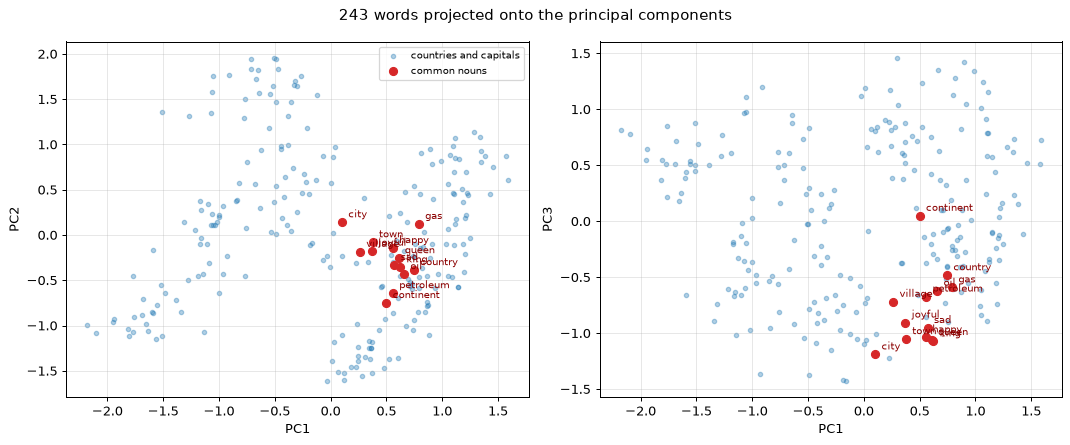

capitals   PC1: mean -0.32, range [-0.67, +0.02]
countries  PC1: mean +1.10, range [+0.91, +1.21]


In [4]:
# everything except these 13 words is a country or a capital
CONCEPTS = ["oil", "gas", "petroleum", "city", "town", "village", "country",
            "continent", "king", "queen", "happy", "sad", "joyful"]
marked = word_vectors.loc[CONCEPTS]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (first, second) in zip(axes, [("x", "y"), ("x", "z")]):
    ax.scatter(word_vectors[first], word_vectors[second], s=12, alpha=0.35,
               color="tab:blue", label="countries and capitals")
    ax.scatter(marked[first], marked[second], s=40, color="tab:red", zorder=3, label="common nouns")
    for word, row in marked.iterrows():
        ax.annotate(word, (row[first], row[second]), textcoords="offset points",
                    xytext=(5, 4), fontsize=8, color="darkred")
    ax.set(xlabel=f"PC{'xyz'.index(first) + 1}", ylabel=f"PC{'xyz'.index(second) + 1}")

axes[0].legend(fontsize=8)
fig.suptitle("243 words projected onto the principal components")
plt.tight_layout()
plt.show()

# the cloud splits into two lobes along PC1 - check what separates them
CAPITALS = ["Paris", "Tokyo", "London", "Berlin", "Madrid", "Rome", "Moscow", "Kiev", "Ottawa", "Canberra"]
COUNTRIES = ["France", "Japan", "England", "Germany", "Spain", "Italy", "Russia", "Ukraine", "Canada", "Australia"]

for label, sample in [("capitals", CAPITALS), ("countries", COUNTRIES)]:
    values = word_vectors.loc[sample, "x"]
    print(f"{label:10s} PC1: mean {values.mean():+.2f}, range [{values.min():+.2f}, {values.max():+.2f}]")

The cloud splits into two lobes along PC1, and the check confirms what separates them: on a sample of ten capitals and ten countries the two groups do not overlap on this axis at all (capitals average $-0.32$ with a maximum of $+0.02$, countries average $+1.10$ with a minimum of $+0.91$). So the very first principal component encodes the country–capital distinction, while the common nouns sit in a tight clump of their own. This is the kind of coarse structure that survives such an aggressive projection.

## Step 2: Finding the Nearest Word

The nearest word to a given vector is the one with the largest **cosine similarity**

$$\cos \theta = \frac{\mathbf{u} \cdot \mathbf{v}}{\lVert \mathbf{u} \rVert \, \lVert \mathbf{v} \rVert}$$

The dot product alone would favour long vectors, and Euclidean distance would do the same in reverse; the cosine looks at direction only. That matters in Step 3, where the cross product produces a vector whose length carries no meaning at all.

In [5]:
MATRIX = word_vectors.to_numpy()
UNIT_MATRIX = MATRIX / np.linalg.norm(MATRIX, axis=1, keepdims=True)


def nearest_words(vector, n=3, exclude=()):
    """Words of the model closest to `vector` by cosine similarity."""
    vector = np.asarray(vector, dtype=np.float64)
    similarities = UNIT_MATRIX @ vector / (np.linalg.norm(vector) + 1e-12)

    ranked = [(words[i], similarities[i]) for i in np.argsort(-similarities) if words[i] not in exclude]
    return pd.DataFrame(ranked[:n], columns=["word", "cosine"])


def show(title, vector, exclude=()):
    print(f"{title}\n{nearest_words(vector, exclude=exclude).to_string(index=False)}\n")


# 1. a word must be its own nearest neighbour
show("vector of 'Japan':", word_vectors.loc["Japan"])

# 2. the same vector with noise added should still resolve to the same word
rng = np.random.default_rng(RANDOM_STATE)
show("vector of 'Japan' + noise:", word_vectors.loc["Japan"] + rng.normal(0, 0.05, 3))

# 3. the midpoint of two words
show("midpoint of 'oil' and 'gas':", (word_vectors.loc["oil"] + word_vectors.loc["gas"]) / 2)

vector of 'Japan':
     word   cosine
    Japan 1.000000
  England 0.998861
Greenland 0.997872

vector of 'Japan' + noise:
     word   cosine
Greenland 0.998803
    Japan 0.998696
  England 0.996170

midpoint of 'oil' and 'gas':
     word   cosine
Greenland 0.998451
  England 0.996217
    Japan 0.994196



The identity check passes exactly, so the function itself is correct. The next two tests already show the limits of a 3D projection. Gaussian noise with $\sigma = 0.05$ — a few percent of a vector whose length is about 1 — is enough to push `Japan` into second place behind `Greenland`. And the midpoint of `oil` and `gas` lands on `Greenland` as well, instead of the expected `petroleum`. The words are packed so tightly here that cosine similarities of 0.99 are ordinary, and the ranking is decided by differences of the same size as the noise.

A harder test is the classic analogy *France is to Paris as ? is to Kiev*, computed as $\text{France} - \text{Paris} + \text{Kiev}$ and evaluated in both spaces:

In [6]:
analogy_3d = word_vectors.loc["France"] - word_vectors.loc["Paris"] + word_vectors.loc["Kiev"]
excluded = ("France", "Paris", "Kiev")

print("3D projection:")
print(nearest_words(analogy_3d, exclude=excluded).to_string(index=False))

full_vectors = pd.DataFrame(original_vectors, index=words)
full_unit = original_vectors / np.linalg.norm(original_vectors, axis=1, keepdims=True)
analogy_full = (full_vectors.loc["France"] - full_vectors.loc["Paris"] + full_vectors.loc["Kiev"]).to_numpy()
similarities = full_unit @ analogy_full / np.linalg.norm(analogy_full)

print("\nOriginal 300D space:")
ranked = [(words[i], similarities[i]) for i in np.argsort(-similarities) if words[i] not in excluded]
print(pd.DataFrame(ranked[:3], columns=["word", "cosine"]).to_string(index=False))

3D projection:
      word   cosine
   Armenia 0.983543
Azerbaijan 0.979930
   Ukraine 0.968012

Original 300D space:
   word   cosine
Ukraine 0.809564
Moldova 0.702466
Belarus 0.685152


In the full space the answer is `Ukraine`, exactly as expected. In the 3D projection `Ukraine` is still in the top three, but behind `Armenia` and `Azerbaijan` — the general "country" direction survives the projection, the identity of the particular country does not.

## Step 3: Cross Product as a Search for an Orthogonal Word

For two 3D vectors the cross product $\mathbf{a} \times \mathbf{b}$ is perpendicular to both, with length $\lVert \mathbf{a} \rVert \lVert \mathbf{b} \rVert \sin \theta$. Applied to word vectors it asks a strange question: which word lies outside the plane spanned by these two? The table records the nearest word to the cross product, the nearest word to the **reversed** product $\mathbf{b} \times \mathbf{a}$, the orthogonality check, and the angle between the two input words.

In [7]:
PAIRS = [("oil", "gas"), ("happy", "sad"), ("king", "queen"), ("Paris", "France"), ("city", "country")]

rows = []
for first, second in PAIRS:
    u, v = word_vectors.loc[first].to_numpy(), word_vectors.loc[second].to_numpy()
    cross = np.cross(u, v)

    forward = nearest_words(cross, n=1, exclude=(first, second)).iloc[0]
    backward = nearest_words(-cross, n=1, exclude=(first, second)).iloc[0]
    cosine = u @ v / (np.linalg.norm(u) * np.linalg.norm(v))

    rows.append(
        {
            "w1": first,
            "w2": second,
            "angle(w1, w2)": np.degrees(np.arccos(np.clip(cosine, -1, 1))),
            "|w1 x w2|": np.linalg.norm(cross),
            "nearest to w1 x w2": forward["word"],
            "cosine": forward["cosine"],
            "nearest to w2 x w1": backward["word"],
            "cos(cross, w1)": float(cross @ u / (np.linalg.norm(cross) * np.linalg.norm(u))),
        }
    )

pd.DataFrame(rows).round(4)

,w1,w2,"angle(w1, w2)",|w1 x w2|,nearest to w1 x w2,cosine,nearest to w2 x w1,"cos(cross, w1)"
0,oil,gas,33.1951,0.5466,Syria,0.9541,Taipei,0.0
1,happy,sad,10.0147,0.2397,Paramaribo,0.9930,Slovenia,0.0
2,king,queen,4.2434,0.1194,Iran,0.9937,Jakarta,0.0
3,Paris,France,99.6189,1.0165,Fiji,0.8888,Zagreb,0.0
4,city,country,59.2376,1.0019,Monrovia,0.9686,Estonia,0.0


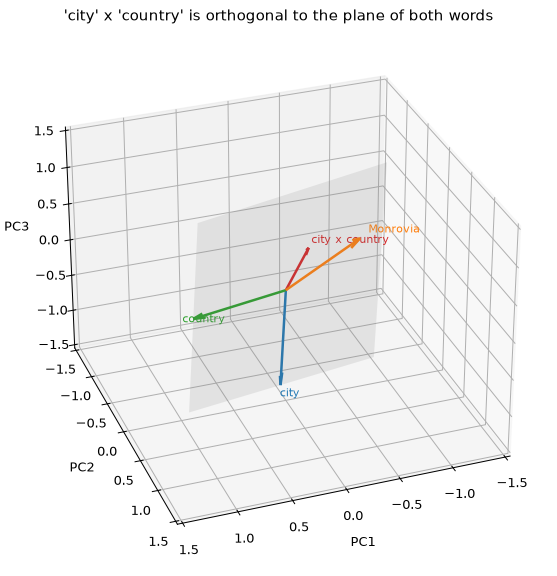

In [8]:
first, second = "city", "country"
u, v = word_vectors.loc[first].to_numpy(), word_vectors.loc[second].to_numpy()
cross = np.cross(u, v)
orthogonal_word = nearest_words(cross, n=1, exclude=(first, second)).iloc[0]["word"]
w = word_vectors.loc[orthogonal_word].to_numpy()

fig = plt.figure(figsize=(7.5, 6.5))
ax = fig.add_subplot(projection="3d")

# the plane spanned by the two words - the cross product must stick out of it
span = np.linspace(-1, 1, 2)
s, t = np.meshgrid(span, span)
plane = s[..., None] * u + t[..., None] * v
ax.plot_surface(plane[..., 0], plane[..., 1], plane[..., 2], alpha=0.15, color="gray")

for vector, label, color in [(u, first, "tab:blue"), (v, second, "tab:green"),
                             (cross, f"{first} x {second}", "tab:red"),
                             (w, orthogonal_word, "tab:orange")]:
    ax.quiver(0, 0, 0, *vector, color=color, arrow_length_ratio=0.12, linewidth=2)
    ax.text(*(vector * 1.12), label, color=color, fontsize=9)

limit = np.abs(np.vstack([u, v, cross, w])).max() * 1.3
ax.set(xlim=(-limit, limit), ylim=(-limit, limit), zlim=(-limit, limit))
ax.set_xlabel("PC1", labelpad=8)
ax.set_ylabel("PC2", labelpad=8)
ax.set_zlabel("PC3", labelpad=8)
ax.view_init(elev=30, azim=70)
ax.set_title(f"'{first}' x '{second}' is orthogonal to the plane of both words")
plt.tight_layout()
plt.show()

**Interpretation.** The orthogonality itself is exact — `cos(cross, w1)` is zero to machine precision, so the operation does what linear algebra promises. The semantics do not follow. The words it returns (`Syria`, `Paramaribo`, `Iran`, `Fiji`, `Monrovia`) have no relation to the pairs that produced them, and reversing the order of the arguments — which only flips the sign, since $\mathbf{a} \times \mathbf{b} = -\mathbf{b} \times \mathbf{a}$ — returns an entirely different word. A meaningful semantic operation cannot depend on the order in which two words are written.

What the cross product does measure usefully is its **length**: $\lVert \mathbf{a} \times \mathbf{b} \rVert = \lVert \mathbf{a} \rVert \lVert \mathbf{b} \rVert \sin \theta$ grows with the angle between the words. For the near-synonyms `king`/`queen` (4.2°) it is 0.12, for the unrelated `city`/`country` (59.2°) it is 1.00 — nearly an order of magnitude apart. Where the dot product measures similarity, the norm of the cross product measures dissimilarity; only the direction of the result is meaningless.

## Step 4: The Angle Between Words

The angle follows from the same cosine:

$$\theta = \arccos \frac{\mathbf{u} \cdot \mathbf{v}}{\lVert \mathbf{u} \rVert \, \lVert \mathbf{v} \rVert}$$

Values are clipped to $[-1, 1]$ before `arccos`, since rounding can push the cosine a fraction beyond the valid range and turn the result into `nan`. Each pair is measured both in the 3D projection and in the original 300D space.

In [9]:
def angle_between(first, second, frame=word_vectors):
    """Angle in degrees between the vectors of two words."""
    u, v = frame.loc[first].to_numpy(), frame.loc[second].to_numpy()
    cosine = u @ v / (np.linalg.norm(u) * np.linalg.norm(v))
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))


TEST_PAIRS = [
    ("happy", "joyful"), ("happy", "sad"), ("oil", "petroleum"), ("oil", "gas"),
    ("city", "town"), ("city", "village"), ("king", "queen"), ("France", "Germany"),
    ("Japan", "Tokyo"), ("Paris", "France"), ("oil", "Tokyo"), ("happy", "Ukraine"),
]

angles = pd.DataFrame(
    [
        {
            "w1": first,
            "w2": second,
            "angle_3d": angle_between(first, second),
            "angle_300d": angle_between(first, second, full_vectors),
        }
        for first, second in TEST_PAIRS
    ]
)
angles["difference"] = angles["angle_3d"] - angles["angle_300d"]
angles.round(1)

,w1,w2,angle_3d,angle_300d,difference
0,happy,joyful,6.5,64.9,-58.4
1,happy,sad,10.0,57.6,-47.6
2,oil,petroleum,12.3,40.0,-27.8
3,oil,gas,33.2,44.7,-11.5
4,city,town,18.3,47.7,-29.4
5,city,village,25.3,61.4,-36.0
6,king,queen,4.2,49.4,-45.1
7,France,Germany,23.4,51.2,-27.8
8,Japan,Tokyo,75.9,45.6,30.4
9,Paris,France,99.6,50.7,48.9


**Interpretation.** In the original space the angles behave as expected: synonyms and words of one topic sit at 40–50° (`oil`/`petroleum` 40.0°, `Japan`/`Tokyo` 45.6°), unrelated words approach 90° (`oil`/`Tokyo` 86.0°, `happy`/`Ukraine` 88.6°). Note that even close synonyms are not at 0° — in a 300-dimensional space random vectors are nearly orthogonal, so 40–50° already means strong similarity, and the scale has to be read relatively, not absolutely.

The 3D column keeps the ordering only in part. Related pairs are compressed hard — `happy`/`joyful` collapses from 64.9° to 6.5°, `king`/`queen` from 49.4° to 4.2° — because the projection discards the directions that separated them, and what is left is their common component. Some pairs move the other way: `Paris`/`France` goes from 50.7° to 99.6°, turning a related pair into an apparently opposite one. Over all 29 403 word pairs the mean discrepancy is 32.4°, which is the quantitative reason the nearest-word searches in Step 2 were unreliable.

## Step 5: How Much Geometry Survives Compression

The natural question is how many components are actually needed. Three measures are tracked against the number of principal components: the variance retained, the mean absolute error of pairwise angles against the original space, and the share of words whose nearest neighbour is still the same word as in 300D.

In [10]:
def pairwise_angles(matrix):
    unit = matrix / np.linalg.norm(matrix, axis=1, keepdims=True)
    return np.degrees(np.arccos(np.clip(unit @ unit.T, -1.0, 1.0)))


def nearest_neighbour_index(matrix):
    unit = matrix / np.linalg.norm(matrix, axis=1, keepdims=True)
    similarity = unit @ unit.T
    np.fill_diagonal(similarity, -np.inf)
    return np.argmax(similarity, axis=1)


upper = np.triu_indices(len(words), k=1)
reference_angles = pairwise_angles(original_vectors)
reference_neighbours = nearest_neighbour_index(original_vectors)

rows = []
for n_components in (2, 3, 5, 10, 25, 50, 100, 243):
    model = PCA(n_components=n_components, random_state=RANDOM_STATE)
    reduced = model.fit_transform(original_vectors)

    rows.append(
        {
            "components": n_components,
            "variance_kept": model.explained_variance_ratio_.sum(),
            "mean_angle_error": np.mean(np.abs(pairwise_angles(reduced)[upper] - reference_angles[upper])),
            "nearest_neighbour_match": np.mean(nearest_neighbour_index(reduced) == reference_neighbours),
        }
    )

compression = pd.DataFrame(rows)
compression.round(3)

,components,variance_kept,mean_angle_error,nearest_neighbour_match
0,2,0.191,44.132,0.016
1,3,0.248,32.373,0.062
2,5,0.337,23.798,0.198
3,10,0.472,18.443,0.333
4,25,0.665,15.748,0.601
5,50,0.817,15.212,0.811
6,100,0.941,15.123,0.872
7,243,1.000,15.120,0.909


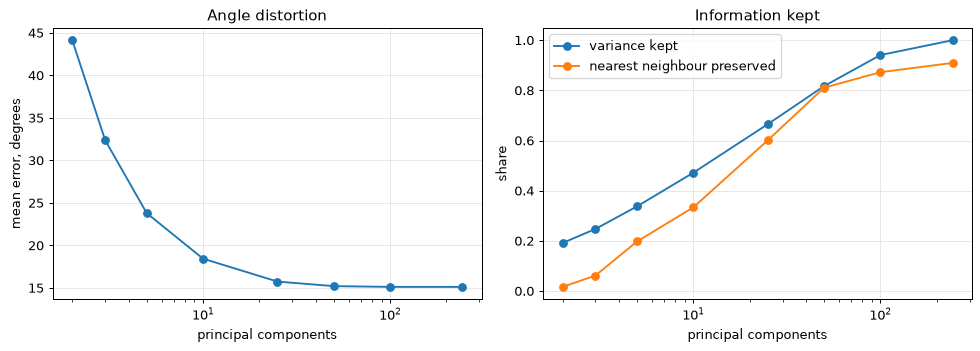

Angle error of the full 243-component PCA against the centered data: 1.46e-14 degrees


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(compression["components"], compression["mean_angle_error"], marker="o")
axes[0].set(title="Angle distortion", xlabel="principal components", ylabel="mean error, degrees", xscale="log")

axes[1].plot(compression["components"], compression["variance_kept"], marker="o", label="variance kept")
axes[1].plot(compression["components"], compression["nearest_neighbour_match"], marker="o", label="nearest neighbour preserved")
axes[1].set(title="Information kept", xlabel="principal components", ylabel="share", xscale="log")
axes[1].legend()
plt.tight_layout()
plt.show()

# the error does not vanish at 243 components - PCA centers the data, and centering changes angles
centered = original_vectors - original_vectors.mean(axis=0)
full_pca = PCA(n_components=243, random_state=RANDOM_STATE).fit_transform(original_vectors)
residual = np.abs(pairwise_angles(full_pca)[upper] - pairwise_angles(centered)[upper]).mean()
print(f"Angle error of the full 243-component PCA against the centered data: {residual:.2e} degrees")

## Conclusion

Three vector operations were applied to word embeddings, and they turn out to be of very unequal value.

**The dot product is the workhorse.** Cosine similarity built on it drives the nearest-word search, and in the full 300D space it behaves exactly as semantics would suggest: `France - Paris + Kiev` returns `Ukraine`, synonyms sit at 40–50°, unrelated words at almost 90°. The absolute scale is counter-intuitive — in high dimensions random vectors are nearly orthogonal, so 45° is already a strong relation — but the ordering is reliable.

**The cross product gives an exact answer to a question that carries no meaning.** The resulting vector is orthogonal to both inputs to machine precision, yet the words it points at (`Syria` for `oil x gas`, `Iran` for `king x queen`) relate to nothing, and swapping the arguments changes the answer completely, because $\mathbf{a} \times \mathbf{b} = -\mathbf{b} \times \mathbf{a}$. Any genuinely semantic operation has to be symmetric in this sense. The useful part of the operation is its magnitude: $\lVert \mathbf{a} \times \mathbf{b} \rVert$ scales with $\sin \theta$ and therefore measures dissimilarity — 0.12 for `king`/`queen` against 1.00 for `city`/`country` — mirroring what the dot product does for similarity. Beyond that, the cross product is defined only in three dimensions, so in NLP it applies only to a projection this aggressive, never to the embeddings themselves.

**The projection to 3D is what breaks most of the results.** Three components keep 24.8% of the variance and only 6% of the nearest-neighbour relations, with a mean angle error of 32.4° — that is why `oil + gas` lands on `Greenland`. PCA is still far better than slicing three raw coordinates (0.9% of the variance), and the compression sweep shows where the useful range begins: 25 components restore 60% of the neighbourhoods, 50 restore 81% at 82% of the variance, and past 100 the gain flattens. So a reasonable working compromise for this model is 50 components, not 3 — three exist here only because the cross product demands them.

One numerical detail worth recording: the angle error does not fall to zero even at the full 243 components, but settles at 15.1°. That is not lost information — PCA centers the data, and angles measured from the centroid differ from angles measured from the origin. Against the centered data the error of the full decomposition is zero to machine precision, as printed above. When cosine similarity is the metric, centering is a change of meaning, not a neutral preprocessing step.